# LOAD & INSPECT DATASET

In [189]:
import pandas as pd
import matplotlib.pyplot as plt

In [190]:
#Load dataset
df=pd.read_csv(r"C:\Users\acer\OneDrive\Desktop\netflix_titles.csv")

In [191]:
#Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [192]:
df.shape

(8807, 12)

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [194]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# 2. DATA CLEANING

# step1:Check Missing Values

In [195]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

# Step 2: Handle Missing Values

In [196]:
df["director"]=df["director"].fillna("Unknown")

In [197]:
df["cast"]=df["cast"].fillna("Not Available")

In [198]:
df["country"]=df["country"].fillna("Unknown")

In [199]:
df=df[~df["rating"].str.contains("min",case=False,na=False)]

In [200]:
df["rating"]=df["rating"].fillna(df["rating"].mode()[0])

In [201]:
#df["duration"]=df["duration"].fillna("Unknown")

In [202]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

# step 3:Fix Data Types

In [203]:
df["date_added"]=pd.to_datetime(df["date_added"],errors="coerce")
df=df.dropna(subset=["date_added"])

Here I converted text to date format

# Step 4:Extracting numeric duration

In [204]:
df["duration_num"]=df["duration"].str.extract('(\d+)')
df["duration_num"]=df["duration_num"].astype(float)
df["duration_num"]=df["duration_num"].fillna(df["duration_num"].median())

Removed text like 'min' and 'Seasons to get numeric values.

# Step 5:Standardizing Text

In [205]:
df["country"]=df["country"].str.strip()
df["type"]=df["type"].str.upper()

cleaned spaces and made text consistent

# Step 6: Removing Duplicates

In [206]:
df.drop_duplicates(inplace=True)

Duplicate rows were removed to ensure data quality

In [207]:
print(df)

     show_id     type                  title         director  \
0         s1    MOVIE   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV SHOW          Blood & Water          Unknown   
2         s3  TV SHOW              Ganglands  Julien Leclercq   
3         s4  TV SHOW  Jailbirds New Orleans          Unknown   
4         s5  TV SHOW           Kota Factory          Unknown   
...      ...      ...                    ...              ...   
8802   s8803    MOVIE                 Zodiac    David Fincher   
8803   s8804  TV SHOW            Zombie Dumb          Unknown   
8804   s8805    MOVIE             Zombieland  Ruben Fleischer   
8805   s8806    MOVIE                   Zoom     Peter Hewitt   
8806   s8807    MOVIE                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                         Not Available  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

# 3.GROUPBY ANALYSIS

# 1.Count Movies vs TV Shows

In [208]:
type_count=df.groupby("type")["show_id"].count()
print(type_count)

type
MOVIE      6128
TV SHOW    2578
Name: show_id, dtype: int64


Groups by type and counts number of records

# 2.Content per Country

In [209]:
df.groupby("country")["show_id"].count().sort_values(ascending=False).head(10)

country
United States     2775
India              971
Unknown            827
United Kingdom     403
Japan              241
South Korea        195
Canada             173
Spain              141
France             122
Mexico             110
Name: show_id, dtype: int64

This groups the data by country and counts the number of titles produced by each country.This helps to identify which country contributes the most content to netflix.

# 3.Average Duration

In [210]:
df.groupby("type")["duration_num"].mean()

type
MOVIE      99.577187
TV SHOW     1.688518
Name: duration_num, dtype: float64

# 4.VISUALIZATIONS

# 1.Bar Chart

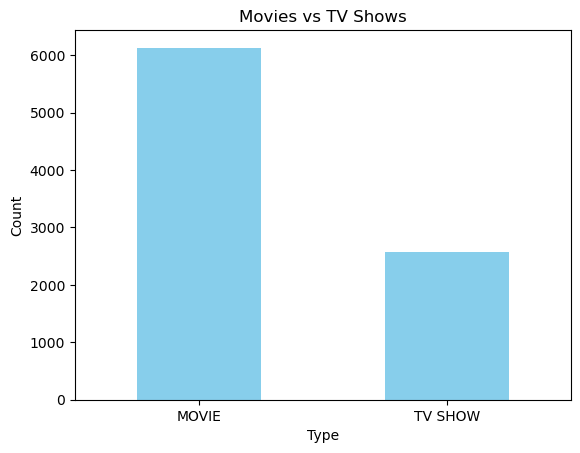

In [213]:
type_count.plot(kind="bar",color="skyblue")
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


A bar chart is used to compare different categories of data. In this chart, the x-axis represents the type of content (movies and TV shows), while the y-axis represents the total count. Each bar corresponds to one category, and its height indicates how many entries belong to that category. This chart makes it easy to visually compare which type of content is more available on Netflix. It is useful for identifying differences between discrete groups.

# 2.Histogram

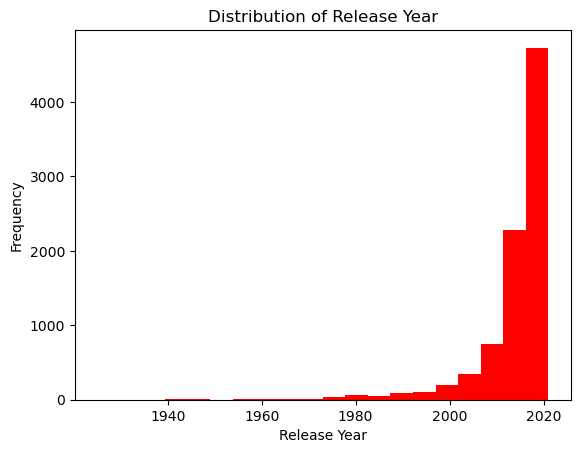

In [221]:
df["release_year"].plot(kind="hist", bins=20,color="red")
plt.title("Distribution of Release Year")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

A histogram is used to show the distribution of a numerical variable. In this case, it displays how Netflix content is distributed across different release years. The x-axis represents the release years, and the y-axis represents the frequency (number of shows released in that period). The data is divided into intervals called bins, and each bar shows how many values fall within that range. This helps in understanding trends, such as whether more content has been produced in recent years.

# 3.Pie Chart

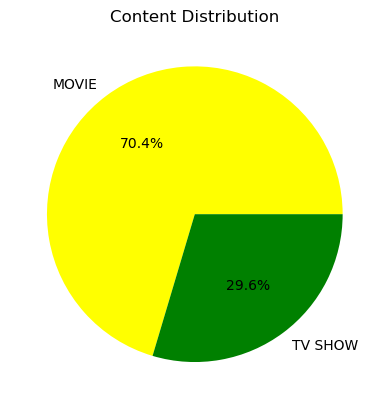

In [220]:
type_count.plot(kind="pie", autopct="%1.1f%%",colors=["yellow","green"])
plt.title("Content Distribution")
plt.ylabel("")
plt.show()

pie chart is used to represent proportions of a whole. Each slice of the pie corresponds to a category, and its size represents the percentage contribution of that category to the total dataset. In this chart, it shows the proportion of movies and TV shows available on Netflix. The percentage labels make it easy to understand how much each category contributes. This chart is useful for quickly identifying dominant categories.

# 4. Scatter Plot

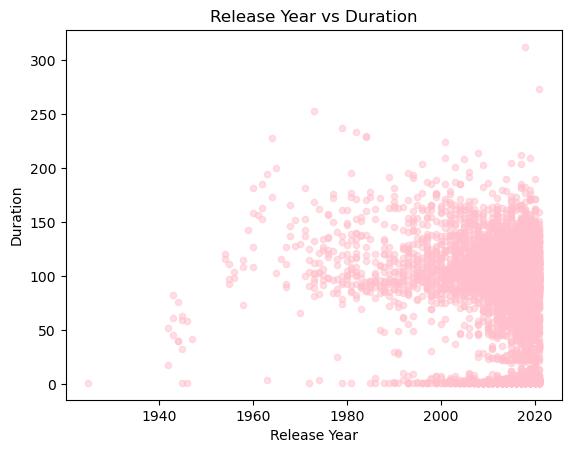

In [224]:
df.plot.scatter(x="release_year", y="duration_num",alpha=0.5,color="pink")
plt.title("Release Year vs Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.show()

A scatter plot is used to analyze the relationship between two numerical variables. In this chart, the x-axis represents the release year and the y-axis represents the duration of the content. Each point corresponds to one entry in the dataset. This visualization helps in identifying patterns or trends, such as whether newer content tends to have longer or shorter durations. It can also reveal clusters or outliers in the data.

# Observation 1:
Most of the content available on Netflix consists of movies, while TV shows are comparatively fewer in number. This indicates that movies dominate the platform.

# Observation 2:
The histogram shows that a large amount of content has been released in recent years, especially after 2015, indicating a growth in content production over time.

# Observation 3:
From the scatter plot, there is no strong relationship between release year and duration, which suggests that content length does not significantly depend on the year it was released.

# Observation 4:
The dataset contains a wide variety of ratings, indicating that Netflix provides content suitable for different age groups, including children, teenagers, and adults.

# Observation 5:
After cleaning the dataset, missing values were handled and inconsistencies were removed, resulting in a more reliable dataset for analysis and visualization.

# What I Would Explore Next

* I would like to analyze which countries produce the most popular or highest-rated content on Netflix.

* I am curious to explore the trend of content added each year to understand how Netflix's growth has changed over time.

* I would also like to compare the duration of movies across different genres to see if certain genres tend to have longer or shorter durations